<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ランダムフォレスト (Random Forest)

In [1]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 24.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=c5e61288aa1ff6b71fed5847d7e7a8337927d6422af12ff907ec5abff0b28eeb
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## 基本的な訓練と評価

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ────────────────────────────
# データの準備
# ────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ────────────────────────────
# モデルの構築と学習
# 注：ランダムフォレストはスケーリング不要
# ────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,       # 木の本数
    max_depth=None,         # 最大深さ（制限なし → 完全に成長）
    max_features='sqrt',    # 各分割で使用する特徴量数
    min_samples_split=2,    # 分割に必要な最小サンプル数
    min_samples_leaf=1,     # 葉ノードの最小サンプル数
    bootstrap=True,         # ブートストラップサンプリングの使用
    oob_score=True,         # OOB スコアの算出
    random_state=42,
    n_jobs=-1               # 全 CPU コアで並列計算
)
rf.fit(X_train, y_train)

# ────────────────────────────
# 予測と評価
# ────────────────────────────
y_pred = rf.predict(X_test)

print(f"テスト正解率:  {accuracy_score(y_test, y_pred):.4f}")
print(f"OOB スコア:    {rf.oob_score_:.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


テスト正解率:  0.8889
OOB スコア:    0.9524

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



## 木の本数と精度の関係

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


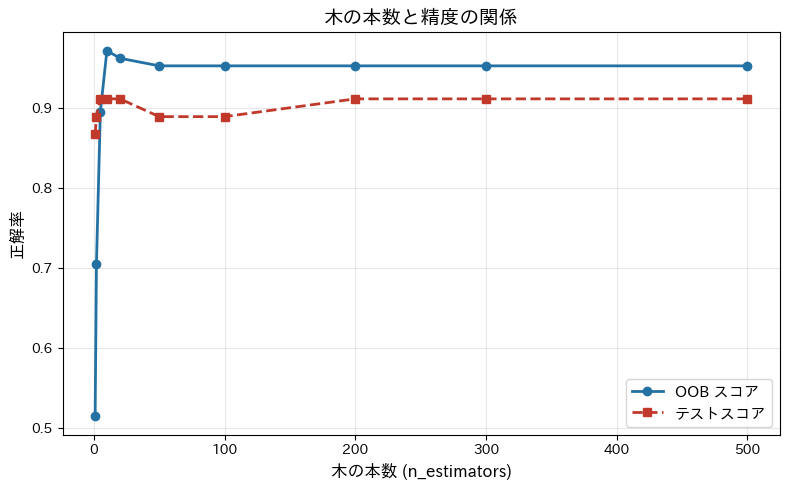

In [3]:
import matplotlib.pyplot as plt
import japanize_matplotlib

n_trees_range = [1, 2, 5, 10, 20, 50, 100, 200, 300, 500]
oob_scores = []
test_scores = []

for n in n_trees_range:
    rf_n = RandomForestClassifier(
        n_estimators=n, oob_score=True, random_state=42, n_jobs=-1
    )
    rf_n.fit(X_train, y_train)
    oob_scores.append(rf_n.oob_score_)
    test_scores.append(rf_n.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_trees_range, oob_scores, 'o-', color='#2471A3',
        linewidth=2, label='OOB スコア')
ax.plot(n_trees_range, test_scores, 's--', color='#C0392B',
        linewidth=2, label='テストスコア')
ax.set_xlabel('木の本数 (n_estimators)', fontsize=12)
ax.set_ylabel('正解率', fontsize=12)
ax.set_title('木の本数と精度の関係', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_n_estimators.png', dpi=150)
plt.show()

# → 木の本数が増えると精度は改善するが，ある時点で飽和する
# → 過学習は起こらない（木を増やしても精度は悪化しない）


## 特徴量重要度の可視化（MDI）

=== 特徴量重要度（MDI）===

  petal width (cm)    : 0.4549 ± 0.3230
  petal length (cm)   : 0.4002 ± 0.3218
  sepal length (cm)   : 0.1206 ± 0.1744
  sepal width (cm)    : 0.0243 ± 0.0327


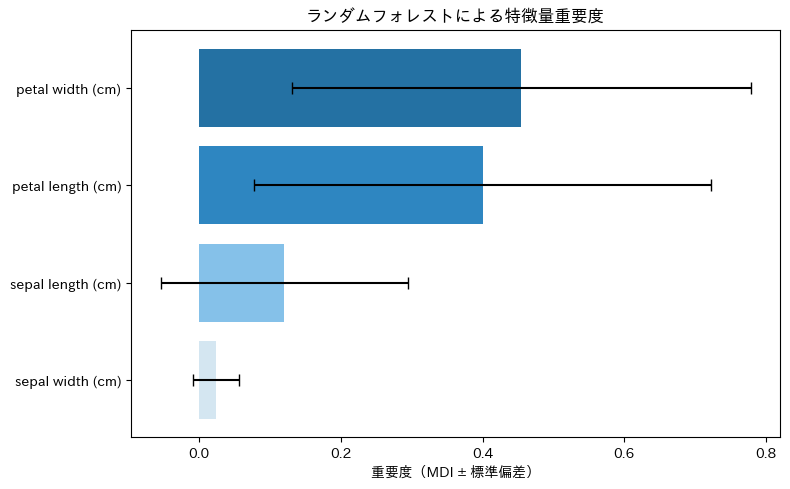

In [4]:
importances = rf.feature_importances_
std = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)
sorted_idx = np.argsort(importances)[::-1]

print("=== 特徴量重要度（MDI）===\n")
for idx in sorted_idx:
    print(f"  {iris.feature_names[idx]:20s}: "
          f"{importances[idx]:.4f} ± {std[idx]:.4f}")

# 棒グラフ
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    range(len(importances)),
    importances[sorted_idx],
    xerr=std[sorted_idx],
    color=['#2471A3', '#2E86C1', '#85C1E9', '#D4E6F1'],
    capsize=4
)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([iris.feature_names[i] for i in sorted_idx])
ax.set_xlabel('重要度（MDI ± 標準偏差）')
ax.set_title('ランダムフォレストによる特徴量重要度')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()


## 順列重要度（Permutation Importance）

=== 順列重要度（テストデータ）===

  petal width (cm)    : 0.1659 ± 0.0362
  petal length (cm)   : 0.1170 ± 0.0334
  sepal width (cm)    : -0.0022 ± 0.0067
  sepal length (cm)   : -0.0185 ± 0.0142


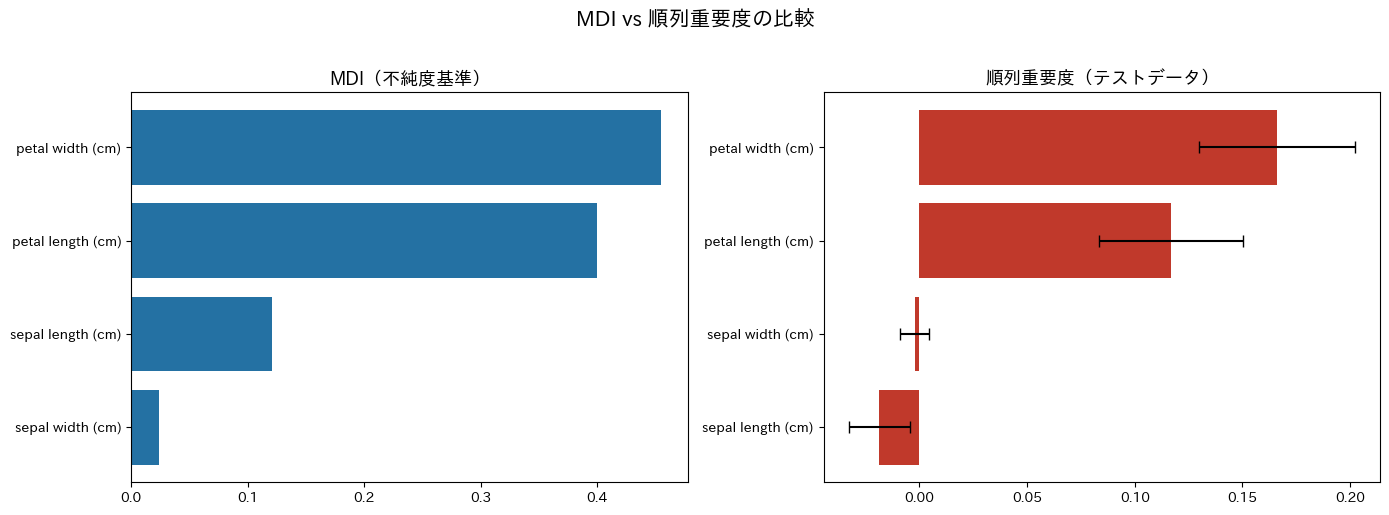

In [5]:
from sklearn.inspection import permutation_importance

# テストデータに対する順列重要度
perm_imp = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
)

print("=== 順列重要度（テストデータ）===\n")
sorted_perm_idx = perm_imp.importances_mean.argsort()[::-1]
for idx in sorted_perm_idx:
    print(f"  {iris.feature_names[idx]:20s}: "
          f"{perm_imp.importances_mean[idx]:.4f} ± "
          f"{perm_imp.importances_std[idx]:.4f}")

# MDI との比較プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(4), importances[sorted_idx], color='#2471A3')
axes[0].set_yticks(range(4))
axes[0].set_yticklabels([iris.feature_names[i] for i in sorted_idx])
axes[0].set_title('MDI（不純度基準）', fontsize=13)
axes[0].invert_yaxis()

axes[1].barh(range(4), perm_imp.importances_mean[sorted_perm_idx],
             xerr=perm_imp.importances_std[sorted_perm_idx],
             color='#C0392B', capsize=4)
axes[1].set_yticks(range(4))
axes[1].set_yticklabels([iris.feature_names[i] for i in sorted_perm_idx])
axes[1].set_title('順列重要度（テストデータ）', fontsize=13)
axes[1].invert_yaxis()

plt.suptitle('MDI vs 順列重要度の比較', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('rf_importance_comparison.png', dpi=150)
plt.show()


## OOB スコアを用いたハイパーパラメータ探索

In [6]:
# max_features の影響を OOB スコアで評価
max_features_options = [1, 2, 3, 4, 'sqrt', 'log2']
print(f"{'max_features':>14s}  |  OOB スコア")
print("-" * 34)

for mf in max_features_options:
    rf_mf = RandomForestClassifier(
        n_estimators=200, max_features=mf,
        oob_score=True, random_state=42, n_jobs=-1
    )
    rf_mf.fit(X_train, y_train)
    print(f"{str(mf):>14s}  |  {rf_mf.oob_score_:.4f}")

# → sqrt (≈ 2) が一般的な推奨値だが，データによって最適値は異なる


  max_features  |  OOB スコア
----------------------------------
             1  |  0.9619
             2  |  0.9524
             3  |  0.9524
             4  |  0.9524
          sqrt  |  0.9524
          log2  |  0.9524


## 決定境界の可視化 ─ 決定木との比較

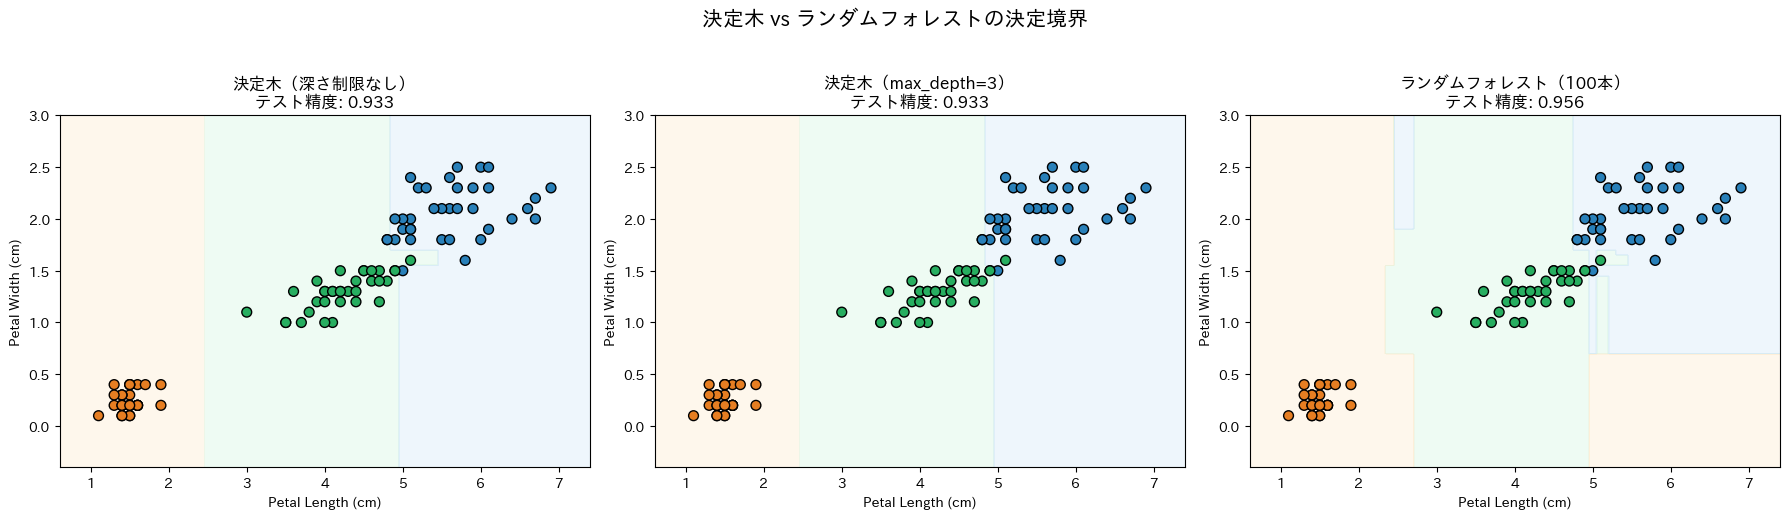

In [7]:
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap

X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)

x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

models = {
    '決定木（深さ制限なし）': DecisionTreeClassifier(random_state=42),
    '決定木（max_depth=3）': DecisionTreeClassifier(max_depth=3, random_state=42),
    'ランダムフォレスト（100本）': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_tr, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = model.score(X_te, y_te)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cmap_pt,
               edgecolors='k', s=50)
    ax.set_title(f'{name}\nテスト精度: {acc:.3f}', fontsize=12)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')

plt.suptitle('決定木 vs ランダムフォレストの決定境界', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('rf_vs_dt_boundary.png', dpi=150)
plt.show()

# → ランダムフォレストの決定境界はより滑らかで安定している


## 不安定性の克服 ─ 決定木との比較実験

=== データ分割 50 通りでの精度比較 ===

                       平均      標準偏差        最小        最大
-------------------------------------------------------
決定木                0.9493    0.0274    0.8889    1.0000
ランダムフォレスト          0.9498    0.0291    0.8889    1.0000


/tmp/ipykernel_427/860400688.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


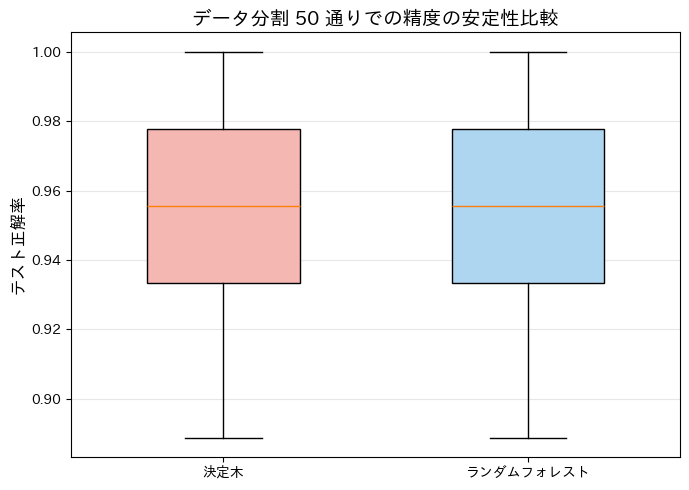

In [8]:
from sklearn.model_selection import cross_val_score

# 異なるランダムシードでの精度のばらつきを比較
dt_scores_list = []
rf_scores_list = []

for seed in range(50):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    # 決定木
    dt_s = DecisionTreeClassifier(random_state=42)
    dt_s.fit(X_tr_s, y_tr_s)
    dt_scores_list.append(dt_s.score(X_te_s, y_te_s))

    # ランダムフォレスト
    rf_s = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_s.fit(X_tr_s, y_tr_s)
    rf_scores_list.append(rf_s.score(X_te_s, y_te_s))

dt_scores = np.array(dt_scores_list)
rf_scores = np.array(rf_scores_list)

print("=== データ分割 50 通りでの精度比較 ===\n")
print(f"{'':15s}  {'平均':>8s}  {'標準偏差':>8s}  {'最小':>8s}  {'最大':>8s}")
print("-" * 55)
print(f"{'決定木':15s}  {dt_scores.mean():8.4f}  {dt_scores.std():8.4f}  "
      f"{dt_scores.min():8.4f}  {dt_scores.max():8.4f}")
print(f"{'ランダムフォレスト':15s}  {rf_scores.mean():8.4f}  {rf_scores.std():8.4f}  "
      f"{rf_scores.min():8.4f}  {rf_scores.max():8.4f}")

# 箱ひげ図
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [dt_scores, rf_scores],
    labels=['決定木', 'ランダムフォレスト'],
    patch_artist=True,
    widths=0.5
)
bp['boxes'][0].set_facecolor('#F5B7B1')
bp['boxes'][1].set_facecolor('#AED6F1')
ax.set_ylabel('テスト正解率', fontsize=12)
ax.set_title('データ分割 50 通りでの精度の安定性比較', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rf_stability.png', dpi=150)
plt.show()

# → ランダムフォレストは精度の平均が高く，ばらつきも小さい


## 個々の木の予測を確認する

In [9]:
# フォレスト内の個々の木の予測を可視化
sample_idx = 0
sample = X_test[sample_idx:sample_idx+1]
true_label = iris.target_names[y_test[sample_idx]]

# 各木の予測を収集
individual_preds = np.array([
    tree.predict(sample)[0] for tree in rf.estimators_
])

# 集計
from collections import Counter
vote_counts = Counter(individual_preds)

print(f"=== サンプル {sample_idx} の予測詳細 ===")
print(f"真のクラス: {true_label}\n")
print(f"各クラスの得票数（{len(rf.estimators_)} 本中）:")
for cls_idx in range(3):
    count = vote_counts.get(cls_idx, 0)
    print(f"  {iris.target_names[cls_idx]:12s}: {count:3d} 票")

print(f"\n最終予測（多数決）: {iris.target_names[rf.predict(sample)[0]]}")
print(f"クラス確率: {rf.predict_proba(sample)[0]}")


=== サンプル 0 の予測詳細 ===
真のクラス: virginica

各クラスの得票数（100 本中）:
  setosa      :   0 票
  versicolor  :   1 票
  virginica   :  99 票

最終予測（多数決）: virginica
クラス確率: [0.   0.01 0.99]


## 大規模データでの他手法との比較

In [10]:
import time
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

X_large, y_large = make_classification(
    n_samples=50000, n_features=30, n_informative=15,
    n_classes=3, random_state=42
)
X_lg_tr, X_lg_te, y_lg_tr, y_lg_te = train_test_split(
    X_large, y_large, test_size=0.3, random_state=42
)

models = {
    'Random Forest (100)':  RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest (500)':  RandomForestClassifier(
        n_estimators=500, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'Logistic Regression':  LogisticRegression(max_iter=300),
    'k-NN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Gaussian NB':          GaussianNB(),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
}

print(f"データ: 訓練={X_lg_tr.shape[0]:,}, テスト={X_lg_te.shape[0]:,}, "
      f"特徴量={X_lg_tr.shape[1]}\n")
print(f"{'モデル':<26s}  {'学習時間':>10s}  {'予測時間':>10s}  {'正解率':>8s}")
print("-" * 62)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_lg_tr, y_lg_tr)
    t_fit = time.time() - t0

    t0 = time.time()
    y_lg_pred = model.predict(X_lg_te)
    t_pred = time.time() - t0

    acc = accuracy_score(y_lg_te, y_lg_pred)
    print(f"{name:<26s}  {t_fit:>9.3f}s  {t_pred:>9.3f}s  {acc:>7.4f}")


データ: 訓練=35,000, テスト=15,000, 特徴量=30

モデル                               学習時間        予測時間       正解率
--------------------------------------------------------------
Random Forest (100)            35.027s      0.248s   0.9259
Random Forest (500)           135.839s      1.237s   0.9303
Gradient Boosting             246.603s      0.090s   0.8378
Logistic Regression             0.812s      0.004s   0.6964
k-NN (k=5)                      0.005s      4.217s   0.9431
Gaussian NB                     0.031s      0.013s   0.6960
Decision Tree                   3.748s      0.005s   0.7801
